In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier


In [8]:
data = load_breast_cancer()
X, y = data.data, data.target

# train / test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)


In [5]:
pip install --upgrade xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

model.fit(X_train, y_train, verbose=True)

preds = model.predict(X_test)
acc = accuracy_score(y_test, preds)
print("Accuracy on test set:", acc)


Accuracy on test set: 0.9385964912280702


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

configs = [0.2, 0.1, 0.03]
results = {}

def train_xgb(lr, n_estimators=800):
    model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=lr,
        eval_metric="logloss",
        random_state=42,
        early_stopping_rounds=20
    )
    
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    return model, acc

for lr in configs:
    model, acc = train_xgb(lr)
    results[lr] = (model, acc)
    print(f"learning_rate={lr}")
    print("  Best iteration:", model.best_iteration + 1)
    print("  Test accuracy :", acc)
    print()   

learning_rate=0.2
  Best iteration: 39
  Test accuracy : 0.9385964912280702

learning_rate=0.1
  Best iteration: 38
  Test accuracy : 0.9385964912280702

learning_rate=0.03
  Best iteration: 144
  Test accuracy : 0.9385964912280702



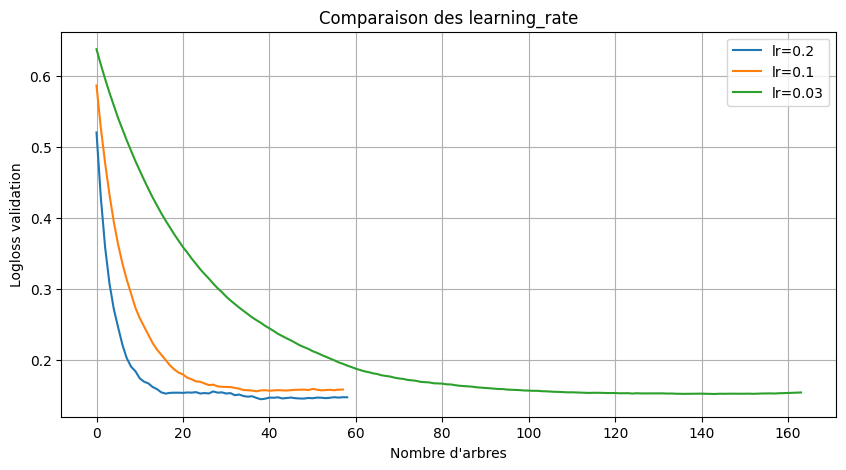

In [16]:
plt.figure(figsize=(10, 5))

for lr in configs:
    model = results[lr][0]
    evals = model.evals_result()

    # Access validation set by correct key — check what's available
    if 'validation_1' in evals:
        val_logloss = evals['validation_1']['logloss']
    elif 'validation_0' in evals:
        val_logloss = evals['validation_0']['logloss']
    else:
        raise KeyError(f"Unexpected evals keys: {list(evals.keys())}")

    plt.plot(val_logloss, label=f"lr={lr}")

plt.xlabel("Nombre d'arbres")
plt.ylabel("Logloss validation")
plt.title("Comparaison des learning_rate")
plt.legend()
plt.grid(True)
plt.show()   

In [17]:
model_no_val = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model_no_val.fit(X_train_full, y_train_full)

preds = model_no_val.predict(X_test)
print("Accuracy sans validation :", accuracy_score(y_test, preds))


Accuracy sans validation : 0.9473684210526315
